In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
data_dir = Path("cleaned_data")
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

yellow_taxi = spark.read.parquet(f"{data_dir / 'yellow_data.parquet'}")
fhvhv_taxi = spark.read.parquet(f"{data_dir / 'fhvhv_data.parquet'}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/23 22:23:58 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/23 22:23:58 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/23 22:23:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where app

In [2]:
yellow_taxi.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|trip_duration|pickup_year|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------+-----------+
|       1| 2023-05-01 00:42:49|  2023-05-01 01:11:18

In [3]:
fhvhv_taxi.show(5)

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|cbd_congestion_fee|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+-------

In [4]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt


def find_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


# ---------------------------------------------------------
# Find relevant columns
# ---------------------------------------------------------

fhv_pickup_col = 'pickup_datetime'
yellow_pickup_col = 'tpep_pickup_datetime'

fhv_money_col = 'driver_pay'

yellow_money_col = 'total_amount'

# ---------------------------------------------------------
# Aggregate FHV data in Spark
# ---------------------------------------------------------

fhv_daily = (
    fhvhv_taxi
    .filter(
        F.col(fhv_pickup_col).isNotNull() &
        F.col(fhv_money_col).isNotNull()
    )
    .groupBy(
        F.to_date(F.col(fhv_pickup_col)).alias("date")
    )
    .agg(
        F.sum(F.col(fhv_money_col)).alias("driver_pay")
    )
)


# ---------------------------------------------------------
# Aggregate Yellow Taxi data in Spark
# ---------------------------------------------------------

yellow_daily = (
    yellow_taxi
    .filter(
        F.col(yellow_pickup_col).isNotNull() &
        F.col(yellow_money_col).isNotNull()
    )
    .groupBy(
        F.to_date(F.col(yellow_pickup_col)).alias("date")
    )
    .agg(
        F.sum(F.col(yellow_money_col)).alias("driver_pay")
    )
)


# ---------------------------------------------------------
# NOW convert to Pandas
# ---------------------------------------------------------
# At this point there should only be ~1 row per day,
# rather than hundreds of millions of rows.

fhv_pd = fhv_daily.toPandas()
yellow_pd = yellow_daily.toPandas()


# Sort in Pandas (tiny datasets, so this is cheap)
fhv_pd = fhv_pd.sort_values("date")
yellow_pd = yellow_pd.sort_values("date")

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


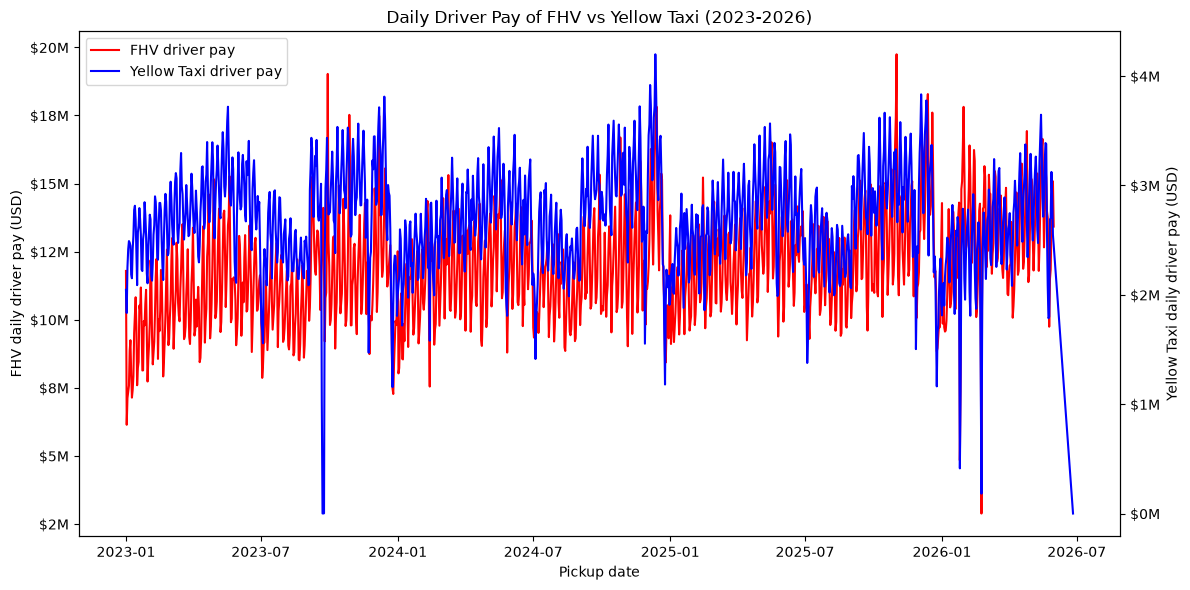

In [5]:
from matplotlib.ticker import FuncFormatter
# ---------------------------------------------------------
# Plot with TWO Y axes
# ---------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: FHV
line1 = ax1.plot(
    fhv_pd["date"],
    fhv_pd["driver_pay"],
    label="FHV driver pay",
    color="red"
)

ax1.set_xlabel("Pickup date")
ax1.set_ylabel("FHV daily driver pay (USD)")


# Right Y-axis: Yellow Taxi
ax2 = ax1.twinx()

line2 = ax2.plot(
    yellow_pd["date"],
    yellow_pd["driver_pay"],
    label="Yellow Taxi driver pay",
    color="blue"
)

ax2.set_ylabel("Yellow Taxi daily driver pay (USD)")


# ---------------------------------------------------------
# Combined legend
# ---------------------------------------------------------

lines = line1 + line2
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000000:,.0f}M"))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1000000:,.0f}M"))
plt.title("Daily Driver Pay of FHV vs Yellow Taxi (2023-2026)")
plt.tight_layout()
plt.show()

In [6]:
# =========================================================
# 1. AGGREGATE YELLOW TAXI TO MONTHLY FREQUENCY
# =========================================================

yellow_monthly = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.sum(F.col("total_amount")).alias("average earnings")
    )
)


# =========================================================
# 2. AGGREGATE FHVHV TO MONTHLY FREQUENCY
# =========================================================

fhvhv_monthly = (
    fhvhv_taxi
    .filter(
        F.col("pickup_datetime").isNotNull() &
        F.col("driver_pay").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.sum(F.col("driver_pay")).alias("average earnings")
    )
)


# =========================================================
# 3. FIND TOP 10 FHVHV LOCATIONS
# =========================================================

fhvhv_top10 = (
    fhvhv_monthly
    .groupBy("PULocationID")
    .agg(
        F.avg(F.col("average earnings")).alias(
            "overall_average_earnings"
        )
    )
    .orderBy(
        F.col("overall_average_earnings").desc()
    )
    .limit(10)
)


# Show the top 10
fhvhv_top10.show()


# =========================================================
# 4. GET MONTHLY FHVHV DATA FOR TOP 10 LOCATIONS
# =========================================================

fhvhv_top10_monthly = (
    fhvhv_monthly
    .join(
        fhvhv_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 5. GET MONTHLY YELLOW TAXI DATA FOR THE SAME
#    TOP 10 FHVHV LOCATIONS
# =========================================================

yellow_top10_monthly = (
    yellow_monthly
    .join(
        fhvhv_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 6. CONVERT ONLY THE SMALL FINAL DATASETS TO PANDAS
# =========================================================

fhvhv_plot_pd = fhvhv_top10_monthly.toPandas()
yellow_plot_pd = yellow_top10_monthly.toPandas()


fhvhv_plot_pd["month"] = pd.to_datetime(
    fhvhv_plot_pd["month"]
)

yellow_plot_pd["month"] = pd.to_datetime(
    yellow_plot_pd["month"]
)


# =========================================================
# 7. GET THE TOP 10 LOCATION IDs
# =========================================================

locations = (
    fhvhv_top10
    .select("PULocationID")
    .rdd
    .flatMap(lambda x: x)
    .collect()
)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+------------+------------------------+
|PULocationID|overall_average_earnings|
+------------+------------------------+
|         132|     1.341481671804878E7|
|         138|     1.181662843121951E7|
|         230|       5347725.888536577|
|         161|       4860088.468780479|
|          79|      4564554.7148780385|
|         231|       4507744.372682921|
|          68|       4427928.832439017|
|          61|       4339338.385609745|
|         164|      4118188.0585365803|
|         246|      4057033.4002438965|
+------------+------------------------+



/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


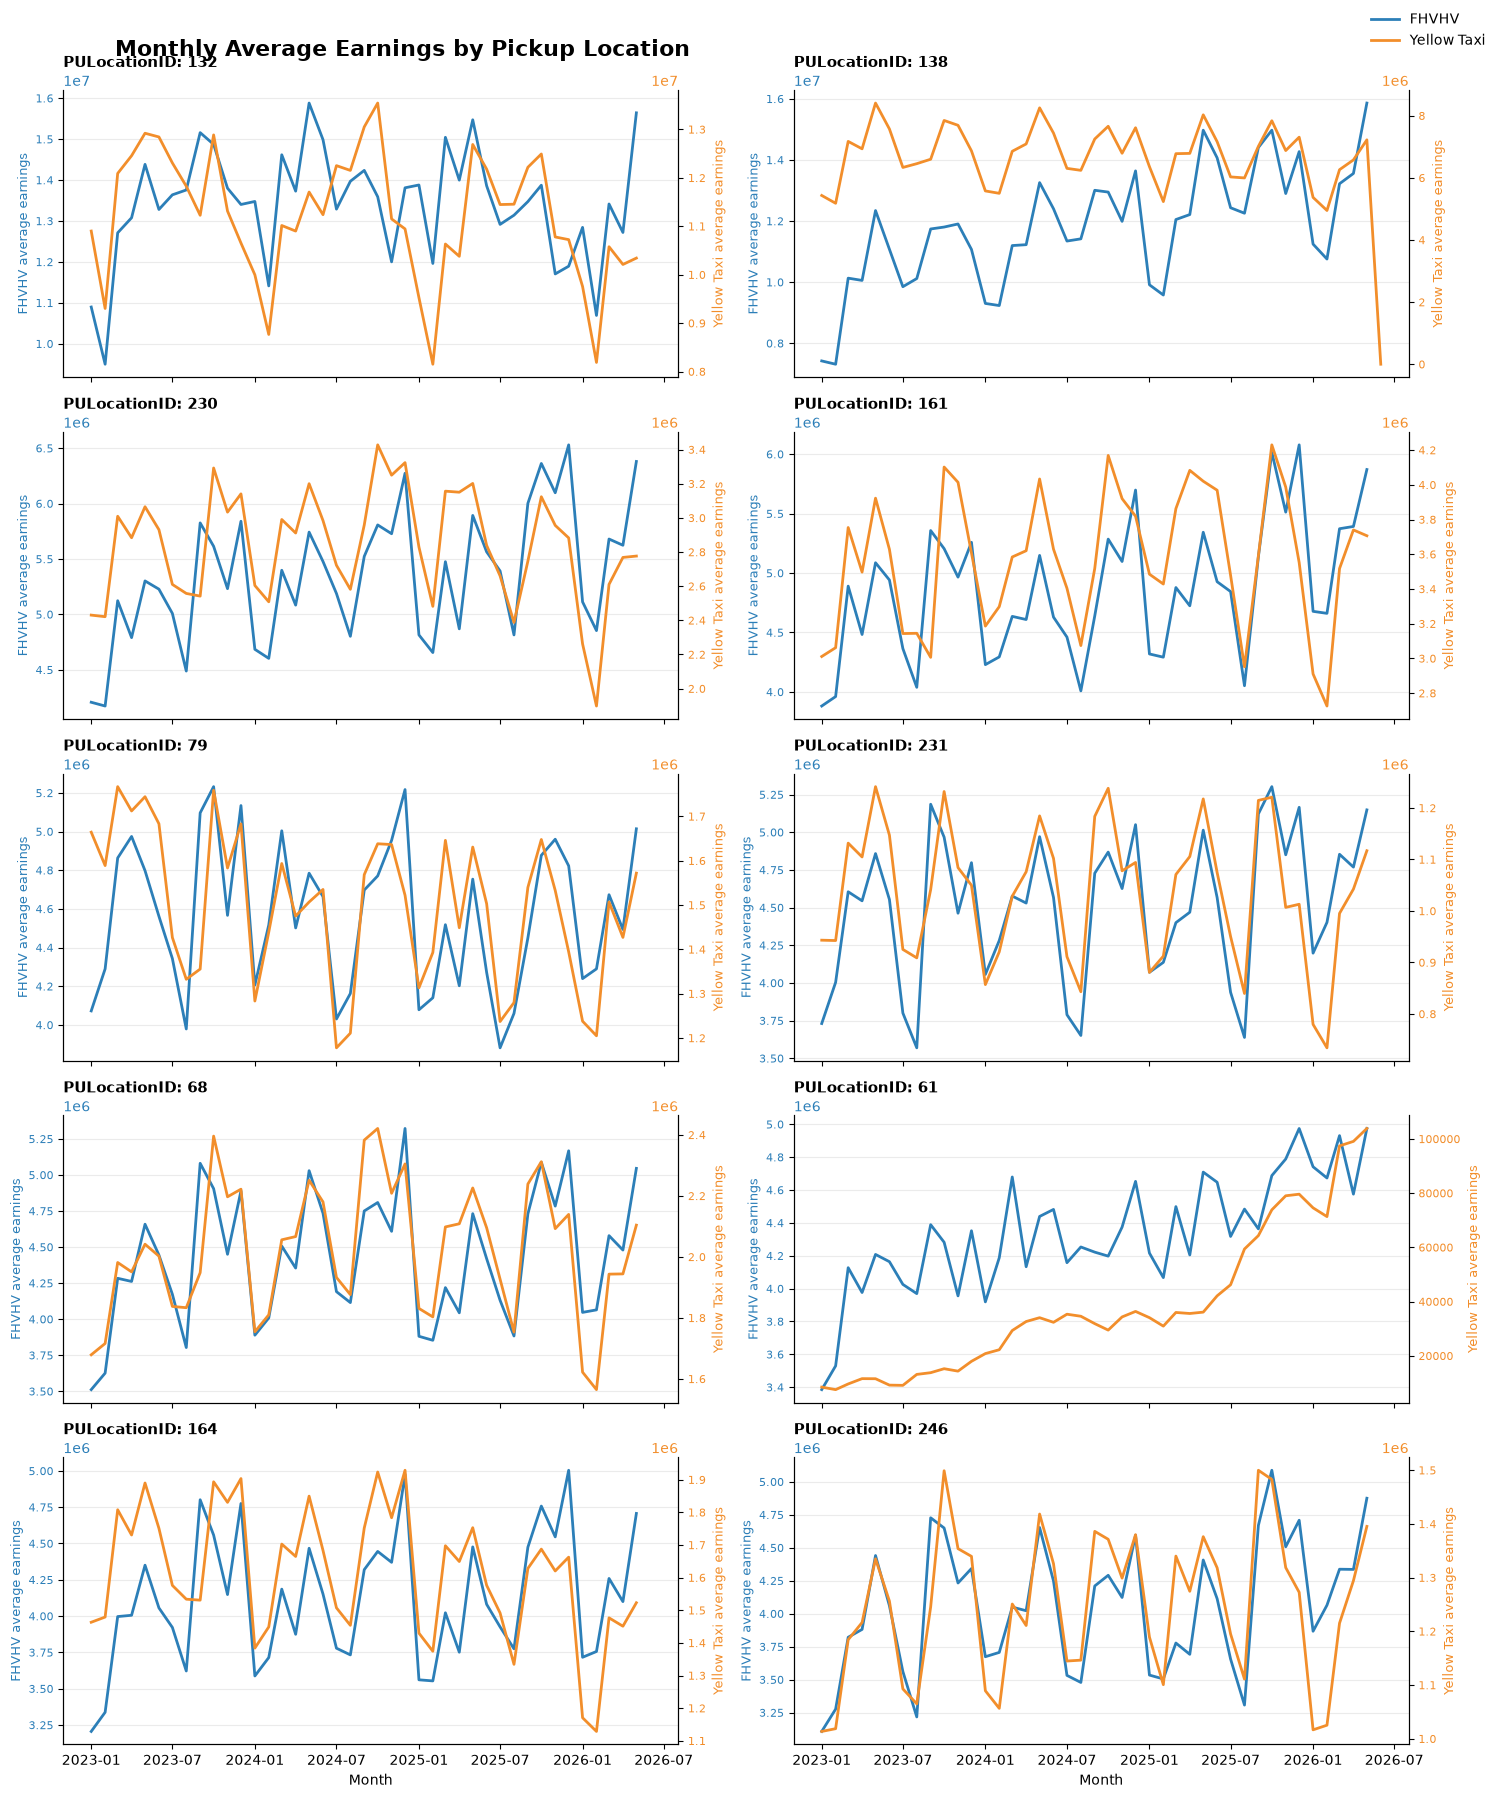

In [7]:
# =========================================================
# 8. CREATE 10 SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 18),
    sharex=True
)

axes = axes.flatten()


# =========================================================
# 9. PLOT FHVHV + YELLOW TAXI ON DUAL Y AXES
# =========================================================

for ax1, location in zip(axes, locations):

    # ---------------------------------------------
    # FHVHV data
    # ---------------------------------------------

    fhvhv_data = (
        fhvhv_plot_pd[
            fhvhv_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # Yellow Taxi data
    # ---------------------------------------------

    yellow_data = (
        yellow_plot_pd[
            yellow_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # LEFT Y-AXIS: FHVHV
    # ---------------------------------------------

    line1 = ax1.plot(
        fhvhv_data["month"],
        fhvhv_data["average earnings"],
        color="#2C7FB8",
        linewidth=2,
        label="FHVHV"
    )

    ax1.set_ylabel(
        "FHVHV average earnings",
        color="#2C7FB8",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#2C7FB8",
        labelsize=8
    )

    # ---------------------------------------------
    # RIGHT Y-AXIS: YELLOW TAXI
    # ---------------------------------------------

    ax2 = ax1.twinx()

    line2 = ax2.plot(
        yellow_data["month"],
        yellow_data["average earnings"],
        color="#F28E2B",
        linewidth=2,
        label="Yellow Taxi"
    )

    ax2.set_ylabel(
        "Yellow Taxi average earnings",
        color="#F28E2B",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#F28E2B",
        labelsize=8
    )

    # ---------------------------------------------
    # SUBPLOT TITLE
    # ---------------------------------------------

    ax1.set_title(
        f"PULocationID: {location}",
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    # ---------------------------------------------
    # GRID / CLEANUP
    # ---------------------------------------------

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    ax1.grid(
        axis="x",
        visible=False
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# =========================================================
# 10. X-AXIS LABELS
# =========================================================

for ax in axes[-2:]:
    ax.set_xlabel(
        "Month",
        fontsize=10
    )


# =========================================================
# 11. OVERALL TITLE
# =========================================================

fig.suptitle(
    "Monthly Average Earnings by Pickup Location",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    ha="left"
)


# =========================================================
# 12. ONE LEGEND FOR THE WHOLE FIGURE
# =========================================================

fig.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            color="#2C7FB8",
            linewidth=2,
            label="FHVHV"
        ),
        plt.Line2D(
            [0],
            [0],
            color="#F28E2B",
            linewidth=2,
            label="Yellow Taxi"
        )
    ],
    loc="upper right",
    frameon=False
)


plt.tight_layout()
plt.show()

In [8]:
# =========================================================
# 1. AGGREGATE YELLOW TAXI TO MONTHLY FREQUENCY
# =========================================================

yellow_monthly = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.avg(F.col("total_amount")).alias("average earnings")
    )
)


# =========================================================
# 2. AGGREGATE FHVHV TO MONTHLY FREQUENCY
# =========================================================

fhvhv_monthly = (
    fhvhv_taxi
    .filter(
        F.col("pickup_datetime").isNotNull() &
        F.col("driver_pay").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .groupBy(
        F.date_trunc(
            "month",
            F.col("pickup_datetime")
        ).alias("month"),
        F.col("PULocationID")
    )
    .agg(
        F.avg(F.col("driver_pay")).alias("average earnings")
    )
)


# =========================================================
# 3. FIND TOP 10 YELLOW TAXI LOCATIONS
# =========================================================
# Yellow Taxi determines the top 10 zones here.

yellow_top10 = (
    yellow_monthly
    .groupBy("PULocationID")
    .agg(
        F.avg(F.col("average earnings")).alias(
            "overall_average_earnings"
        )
    )
    .orderBy(
        F.col("overall_average_earnings").desc()
    )
    .limit(10)
)


# Show the top 10 Yellow Taxi locations
yellow_top10.show()


# =========================================================
# 4. GET MONTHLY YELLOW TAXI DATA FOR TOP 10 LOCATIONS
# =========================================================

yellow_top10_monthly = (
    yellow_monthly
    .join(
        yellow_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 5. GET MONTHLY FHVHV DATA FOR THE SAME
#    TOP 10 YELLOW TAXI LOCATIONS
# =========================================================

fhvhv_top10_monthly = (
    fhvhv_monthly
    .join(
        yellow_top10.select("PULocationID"),
        on="PULocationID",
        how="inner"
    )
)


# =========================================================
# 6. CONVERT ONLY THE SMALL FINAL DATASETS TO PANDAS
# =========================================================

yellow_plot_pd = yellow_top10_monthly.toPandas()
fhvhv_plot_pd = fhvhv_top10_monthly.toPandas()


yellow_plot_pd["month"] = pd.to_datetime(
    yellow_plot_pd["month"]
)

fhvhv_plot_pd["month"] = pd.to_datetime(
    fhvhv_plot_pd["month"]
)


# =========================================================
# 7. GET THE TOP 10 LOCATION IDs
# =========================================================

locations = (
    yellow_top10
    .select("PULocationID")
    .rdd
    .flatMap(lambda x: x)
    .collect()
)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+------------+------------------------+
|PULocationID|overall_average_earnings|
+------------+------------------------+
|           1|       88.85070971288306|
|         204|       80.65666666666665|
|         132|       74.11016255529952|
|           5|       72.67732439758127|
|          10|       72.41969705647445|
|          93|       72.11221645225133|
|         138|       66.24853726543414|
|           8|       66.12125120907983|
|         219|       64.69773388025378|
|         251|        64.3740170068027|
+------------+------------------------+



/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


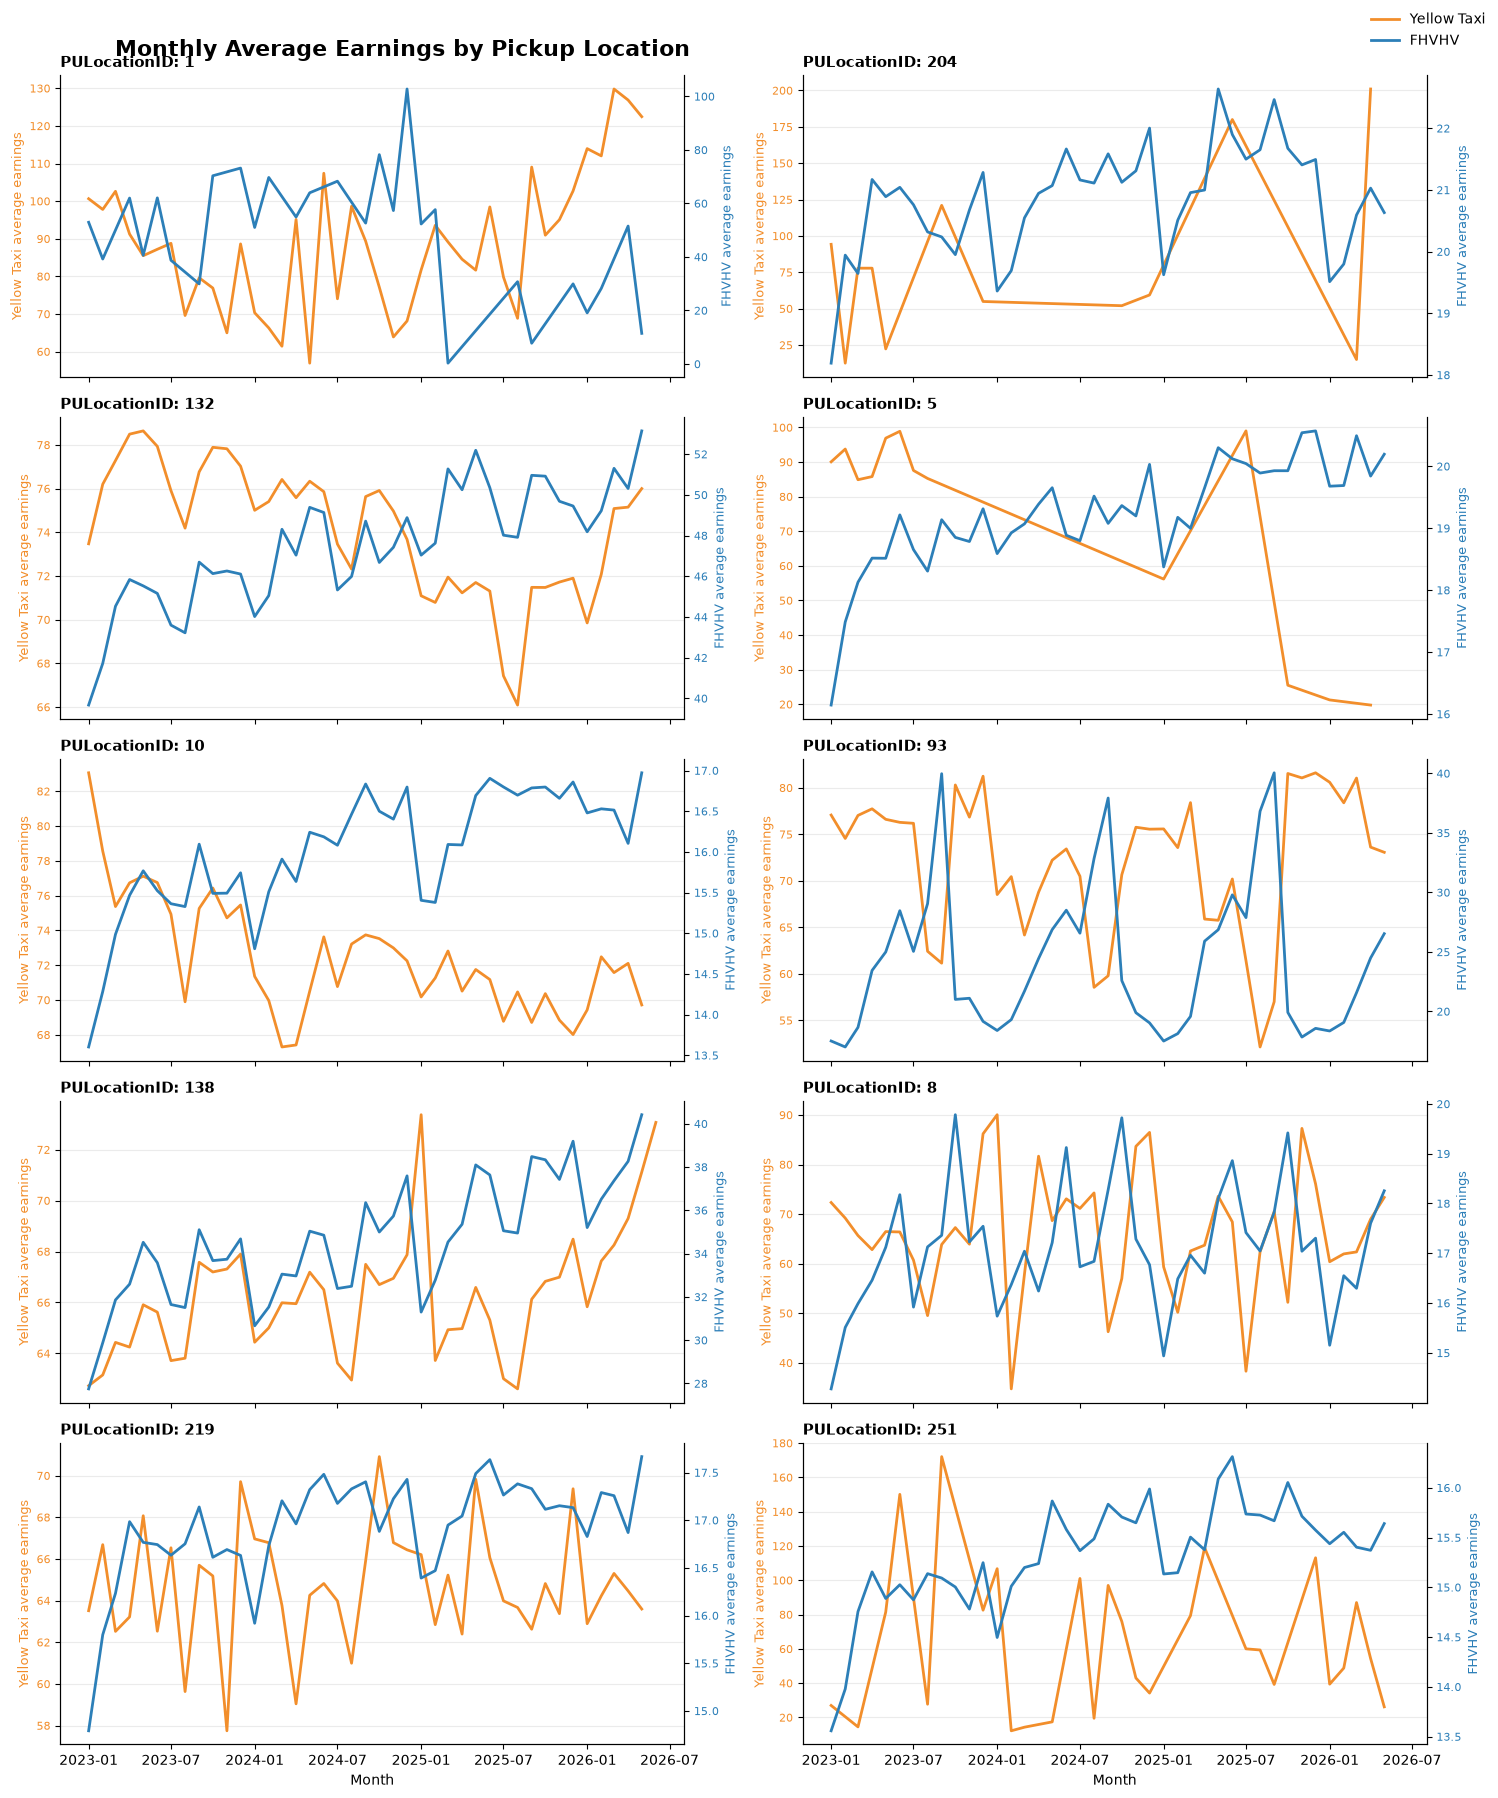

In [9]:
# =========================================================
# 8. CREATE 10 SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 18),
    sharex=True
)

axes = axes.flatten()


# =========================================================
# 9. PLOT YELLOW TAXI + FHVHV ON DUAL Y AXES
# =========================================================

for ax1, location in zip(axes, locations):

    # ---------------------------------------------
    # Yellow Taxi data
    # ---------------------------------------------

    yellow_data = (
        yellow_plot_pd[
            yellow_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # FHVHV data
    # ---------------------------------------------

    fhvhv_data = (
        fhvhv_plot_pd[
            fhvhv_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # LEFT Y-AXIS: YELLOW TAXI
    # ---------------------------------------------

    line1 = ax1.plot(
        yellow_data["month"],
        yellow_data["average earnings"],
        color="#F28E2B",
        linewidth=2,
        label="Yellow Taxi"
    )

    ax1.set_ylabel(
        "Yellow Taxi average earnings",
        color="#F28E2B",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#F28E2B",
        labelsize=8
    )

    # ---------------------------------------------
    # RIGHT Y-AXIS: FHVHV
    # ---------------------------------------------

    ax2 = ax1.twinx()

    line2 = ax2.plot(
        fhvhv_data["month"],
        fhvhv_data["average earnings"],
        color="#2C7FB8",
        linewidth=2,
        label="FHVHV"
    )

    ax2.set_ylabel(
        "FHVHV average earnings",
        color="#2C7FB8",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#2C7FB8",
        labelsize=8
    )

    # ---------------------------------------------
    # SUBPLOT TITLE
    # ---------------------------------------------

    ax1.set_title(
        f"PULocationID: {location}",
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    # ---------------------------------------------
    # GRID / CLEANUP
    # ---------------------------------------------

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    ax1.grid(
        axis="x",
        visible=False
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# =========================================================
# 10. X-AXIS LABELS
# =========================================================

for ax in axes[-2:]:
    ax.set_xlabel(
        "Month",
        fontsize=10
    )


# =========================================================
# 11. OVERALL TITLE
# =========================================================

fig.suptitle(
    "Monthly Average Earnings by Pickup Location",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    ha="left"
)


# =========================================================
# 12. ONE LEGEND FOR THE WHOLE FIGURE
# =========================================================

fig.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            color="#F28E2B",
            linewidth=2,
            label="Yellow Taxi"
        ),
        plt.Line2D(
            [0],
            [0],
            color="#2C7FB8",
            linewidth=2,
            label="FHVHV"
        )
    ],
    loc="upper right",
    frameon=False
)


plt.tight_layout()
plt.show()

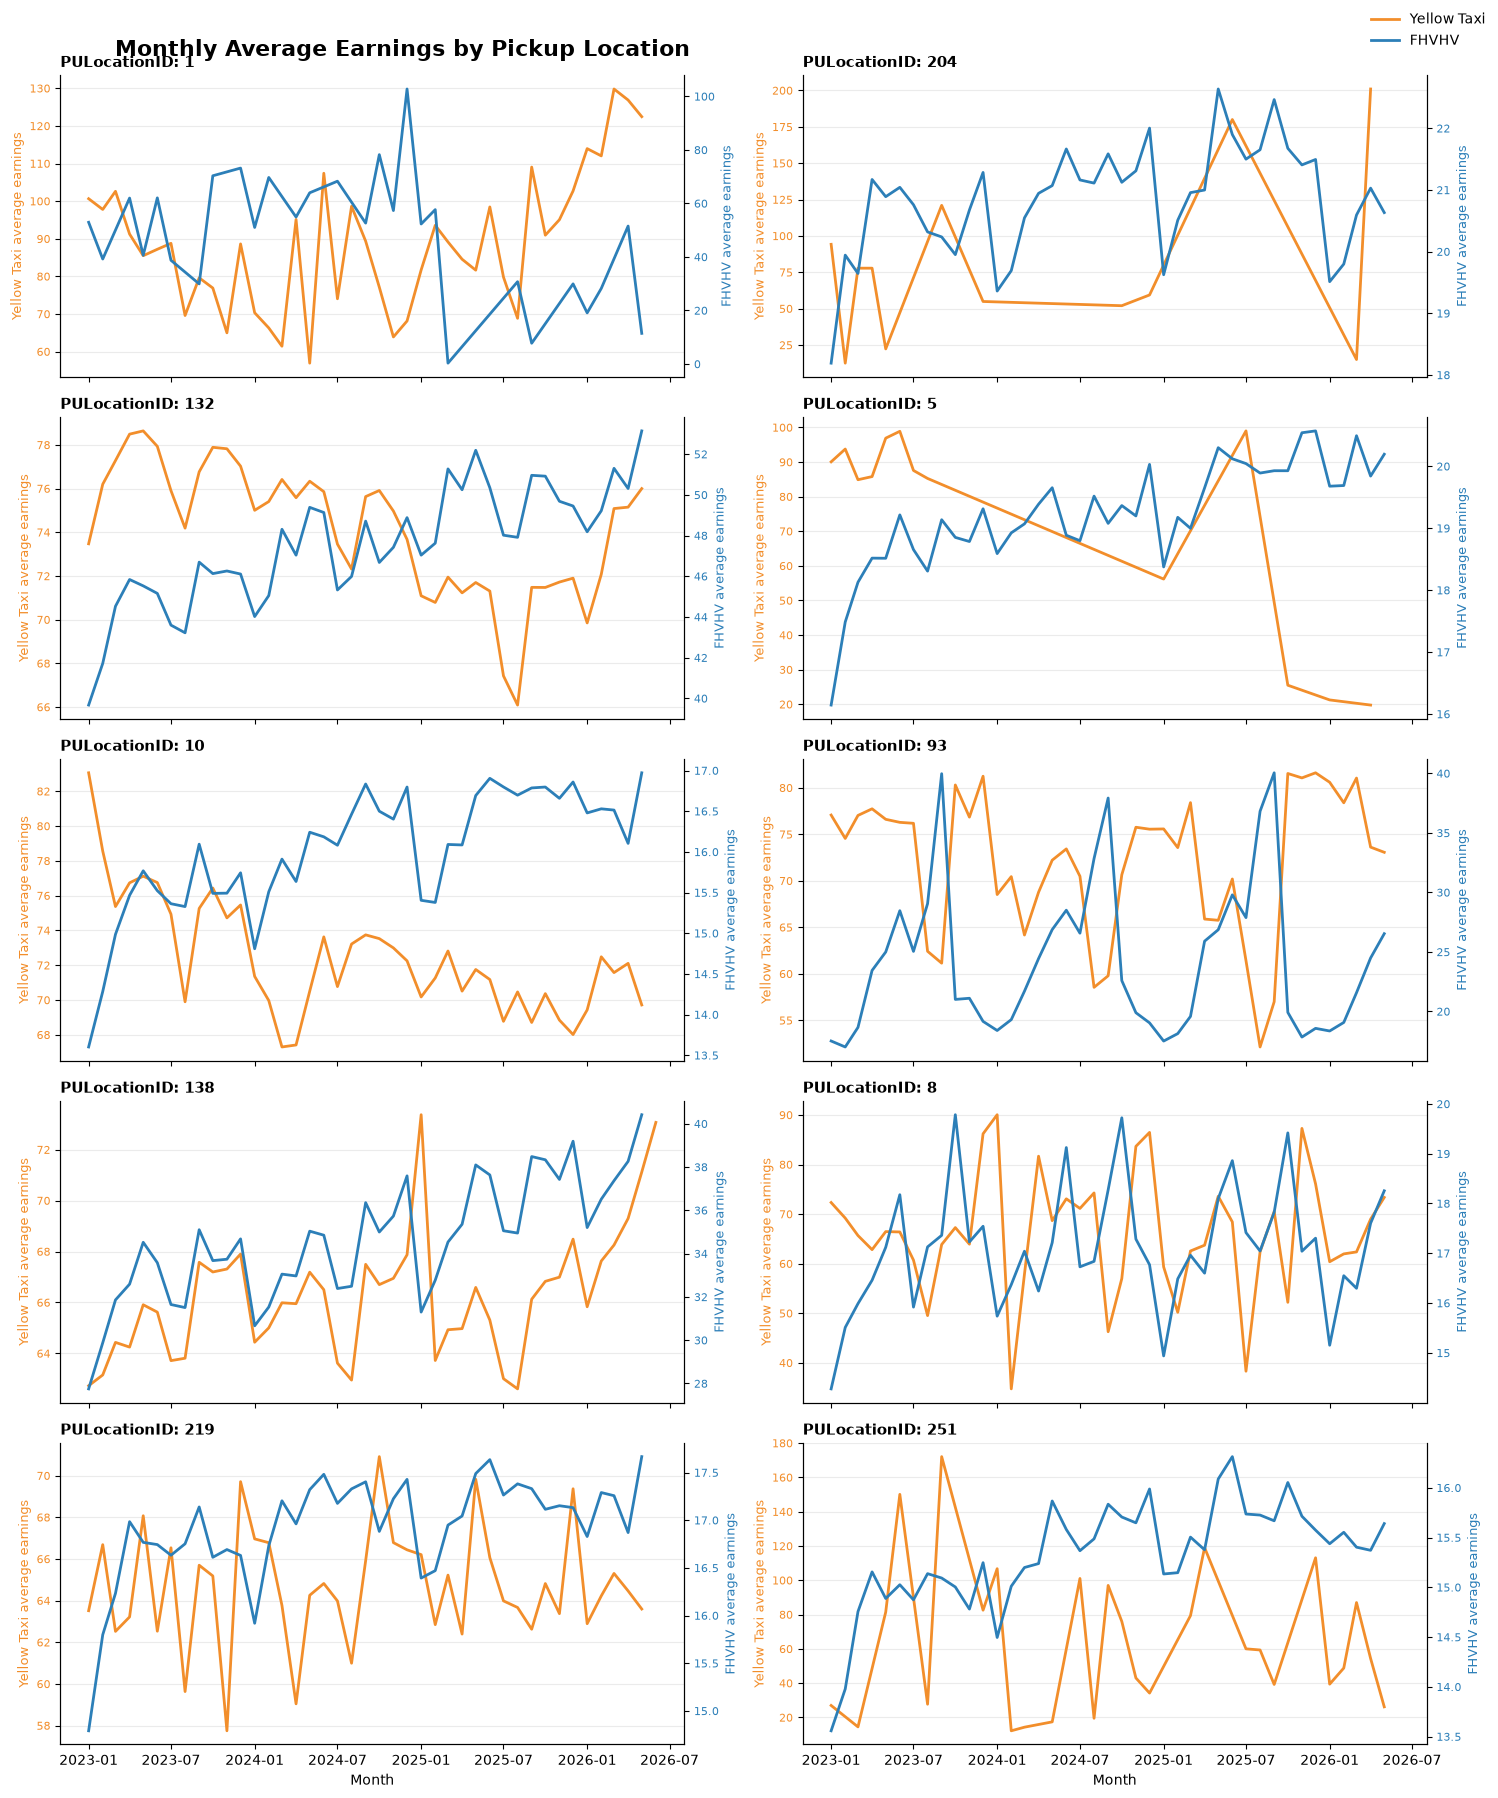

In [10]:
# =========================================================
# 8. CREATE 10 SUBPLOTS
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(15, 18),
    sharex=True
)

axes = axes.flatten()


# =========================================================
# 9. PLOT YELLOW TAXI + FHVHV ON DUAL Y AXES
# =========================================================

for ax1, location in zip(axes, locations):

    # ---------------------------------------------
    # Yellow Taxi data
    # ---------------------------------------------

    yellow_data = (
        yellow_plot_pd[
            yellow_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # FHVHV data
    # ---------------------------------------------

    fhvhv_data = (
        fhvhv_plot_pd[
            fhvhv_plot_pd["PULocationID"] == location
        ]
        .sort_values("month")
    )

    # ---------------------------------------------
    # LEFT Y-AXIS: YELLOW TAXI
    # ---------------------------------------------

    line1 = ax1.plot(
        yellow_data["month"],
        yellow_data["average earnings"],
        color="#F28E2B",
        linewidth=2,
        label="Yellow Taxi"
    )

    ax1.set_ylabel(
        "Yellow Taxi average earnings",
        color="#F28E2B",
        fontsize=9
    )

    ax1.tick_params(
        axis="y",
        labelcolor="#F28E2B",
        labelsize=8
    )

    # ---------------------------------------------
    # RIGHT Y-AXIS: FHVHV
    # ---------------------------------------------

    ax2 = ax1.twinx()

    line2 = ax2.plot(
        fhvhv_data["month"],
        fhvhv_data["average earnings"],
        color="#2C7FB8",
        linewidth=2,
        label="FHVHV"
    )

    ax2.set_ylabel(
        "FHVHV average earnings",
        color="#2C7FB8",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="#2C7FB8",
        labelsize=8
    )

    # ---------------------------------------------
    # SUBPLOT TITLE
    # ---------------------------------------------

    ax1.set_title(
        f"PULocationID: {location}",
        fontsize=11,
        fontweight="bold",
        loc="left"
    )

    # ---------------------------------------------
    # GRID / CLEANUP
    # ---------------------------------------------

    ax1.grid(
        axis="y",
        alpha=0.25
    )

    ax1.grid(
        axis="x",
        visible=False
    )

    ax1.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# =========================================================
# 10. X-AXIS LABELS
# =========================================================

for ax in axes[-2:]:
    ax.set_xlabel(
        "Month",
        fontsize=10
    )


# =========================================================
# 11. OVERALL TITLE
# =========================================================

fig.suptitle(
    "Monthly Average Earnings by Pickup Location",
    fontsize=16,
    fontweight="bold",
    x=0.08,
    ha="left"
)


# =========================================================
# 12. ONE LEGEND FOR THE WHOLE FIGURE
# =========================================================

fig.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            color="#F28E2B",
            linewidth=2,
            label="Yellow Taxi"
        ),
        plt.Line2D(
            [0],
            [0],
            color="#2C7FB8",
            linewidth=2,
            label="FHVHV"
        )
    ],
    loc="upper right",
    frameon=False
)


plt.tight_layout()
plt.show()

In [11]:
zone_lookup = spark.read.csv("data/taxi_zone_lookup.csv", header=True, inferSchema=True)
zone_lookup.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


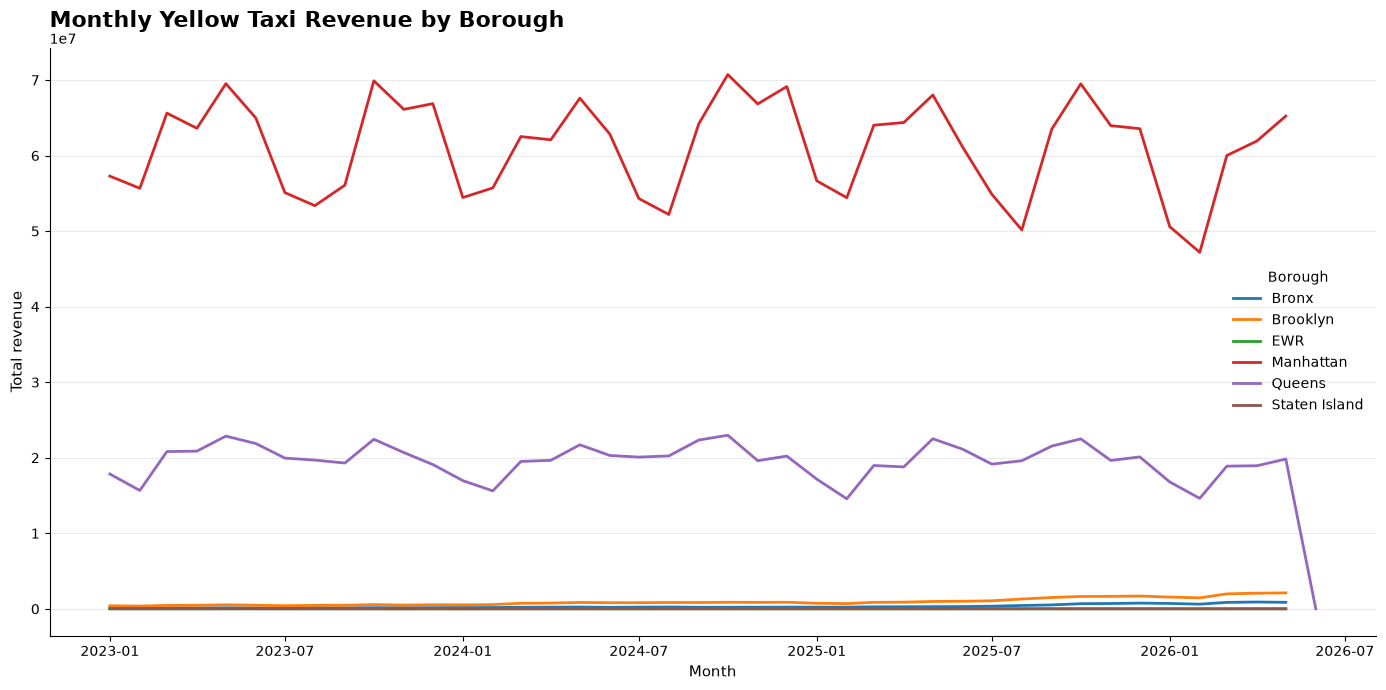

In [12]:
# =========================================================
# 1. PREPARE THE ZONE LOOKUP TABLE
# =========================================================

zone_lookup_clean = (
    zone_lookup
    .select(
        F.col("LocationID"),
        F.col("Borough")
    )
)


# =========================================================
# 2. JOIN YELLOW TAXI DATA TO BOROUGH INFORMATION
# =========================================================

yellow_with_borough = (
    yellow_taxi
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )
    .join(
        zone_lookup_clean,
        yellow_taxi["PULocationID"] == zone_lookup_clean["LocationID"],
        how="inner"
    )
)


# =========================================================
# 3. AGGREGATE TO MONTHLY TOTAL REVENUE BY BOROUGH
# =========================================================

borough_monthly_revenue = (
    yellow_with_borough
    .groupBy(
        F.date_trunc(
            "month",
            F.col("tpep_pickup_datetime")
        ).alias("month"),
        F.col("Borough")
    )
    .agg(
        F.sum(
            F.col("total_amount")
        ).alias("total_revenue")
    )
    .orderBy(
        "month",
        "Borough"
    )
)



# =========================================================
# 4. CONVERT THE SMALL AGGREGATED DATASET TO PANDAS
# =========================================================

borough_pd = borough_monthly_revenue.toPandas()

borough_pd["month"] = pd.to_datetime(
    borough_pd["month"]
)


# =========================================================
# 5. PLOT MONTHLY REVENUE FOR EACH BOROUGH
# =========================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


for borough in borough_pd["Borough"].unique():

    borough_data = (
        borough_pd[
            borough_pd["Borough"] == borough
        ]
        .sort_values("month")
    )

    ax.plot(
        borough_data["month"],
        borough_data["total_revenue"],
        linewidth=2,
        label=borough
    )


# =========================================================
# 6. CLEAN UP THE PLOT
# =========================================================

ax.set_title(
    "Monthly Yellow Taxi Revenue by Borough",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=15
)

ax.set_xlabel(
    "Month",
    fontsize=11
)

ax.set_ylabel(
    "Total revenue",
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Borough",
    frameon=False
)

plt.tight_layout()
plt.show()

In [13]:
X = (
    yellow_taxi

    # Keep valid timestamps, revenue, and pickup locations
    .filter(
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("total_amount").isNotNull() &
        F.col("PULocationID").isNotNull()
    )

    # Extract calendar date
    .withColumn(
        "date",
        F.to_date("tpep_pickup_datetime")
    )

    # Day of week:
    # Monday = 1, Tuesday = 2, ..., Sunday = 7
    .withColumn(
        "day",
        ((F.dayofweek("tpep_pickup_datetime") + 5) % 7) + 1
    )

    # Numeric month:
    # January = 1, ..., December = 12
    .withColumn(
        "month",
        F.month("tpep_pickup_datetime")
    )

    # Aggregate daily revenue by pickup location
    .groupBy(
        "date",
        "day",
        "month",
        "PULocationID"
    )
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
)
print(X.count())
X.show()

270860


+----------+---+-----+------------+------------------+
|      date|day|month|PULocationID|     total_revenue|
+----------+---+-----+------------+------------------+
|2023-05-08|  1|    5|         186| 84532.24000000008|
|2023-05-02|  2|    5|         139|             180.0|
|2023-05-03|  3|    5|         236|115552.53000000022|
|2023-05-03|  3|    5|          97| 583.4499999999999|
|2023-05-03|  3|    5|         224|2860.6799999999994|
|2023-05-05|  5|    5|         186| 85474.53000000023|
|2023-05-06|  6|    5|         260|            491.88|
|2023-05-10|  3|    5|          24| 7546.660000000004|
|2023-05-10|  3|    5|         194|             96.66|
|2023-05-11|  4|    5|         143| 29651.54000000002|
|2023-05-11|  4|    5|         159|              87.9|
|2023-05-12|  5|    5|         234| 77870.87999999992|
|2023-05-12|  5|    5|          74|5560.2400000000025|
|2023-05-14|  7|    5|         256|1218.5700000000002|
|2023-05-14|  7|    5|         232|3524.5200000000004|
|2023-05-1

In [14]:
import geopandas as gpd
station_data = spark.read.csv("data/station_data.csv", header=True, inferSchema=True)
taxi_zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")
station_data.show()

+------------+----------+----------+--------+-------------------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+-----------+--------------------+
|GTFS Stop ID|Station ID|Complex ID|Division|               Line|           Stop Name|Borough|  CBD|Daytime Routes|Structure|GTFS Latitude|GTFS Longitude|North Direction Label|South Direction Label|ADA|ADA Northbound|ADA Southbound|  ADA Notes|        Georeference|
+------------+----------+----------+--------+-------------------+--------------------+-------+-----+--------------+---------+-------------+--------------+---------------------+---------------------+---+--------------+--------------+-----------+--------------------+
|         R01|         1|         1|     BMT|            Astoria|Astoria-Ditmars Blvd|      Q|false|           N W| Elevated|    40.775036|    -73.912034|            Last Stop|            Manhattan|  0|

In [15]:
station_pd = station_data.toPandas()
station_gdf = gpd.GeoDataFrame(
    station_pd,
    geometry=gpd.points_from_xy(
        station_pd["GTFS Longitude"],
        station_pd["GTFS Latitude"]
    ),
    crs="EPSG:4326"
).to_crs(taxi_zones.crs)

# 3) Keep taxi zone id + geometry (OBJECTID corresponds to PULocationID)
zones_gdf = taxi_zones[["OBJECTID", "geometry"]].copy()

# 4) Spatial join: station point within taxi zone polygon
stations_with_zone = gpd.sjoin(
    station_gdf,
    zones_gdf,
    how="left",
    predicate="within"
)

# 5) Count stations per zone, include zones with zero stations
station_counts_pd = (
    zones_gdf[["OBJECTID"]]
    .merge(
        stations_with_zone.groupby("OBJECTID").size().reset_index(name="num_stations"),
        on="OBJECTID",
        how="left"
    )
    .fillna({"num_stations": 0})
)

station_counts_pd["PULocationID"] = station_counts_pd["OBJECTID"].astype(int)
station_counts_pd["num_stations"] = station_counts_pd["num_stations"].astype(int)

# 6) Pandas -> Spark
num_stations_df = spark.createDataFrame(
    station_counts_pd[["PULocationID", "num_stations"]]
).orderBy("PULocationID")

X = (
    X
    .join(
        num_stations_df.select(
            "PULocationID",
            "num_stations"
        ),
        on="PULocationID",
        how="left"
    )
)
X.show(5)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

+------------+----------+---+-----+------------------+------------+
|PULocationID|      date|day|month|     total_revenue|num_stations|
+------------+----------+---+-----+------------------+------------+
|         186|2023-05-08|  1|    5| 84532.24000000008|           4|
|         139|2023-05-02|  2|    5|             180.0|           0|
|         236|2023-05-03|  3|    5|115552.53000000022|           2|
|          97|2023-05-03|  3|    5| 583.4499999999999|           6|
|         224|2023-05-03|  3|    5|2860.6799999999994|           0|
+------------+----------+---+-----+------------------+------------+
only showing top 5 rows


In [16]:
unemployment_data = spark.read.csv("data/unemployment.csv", header=True, inferSchema=True)
print(unemployment_data.count())
unemployment_data.show(5)

2773
+----+-----+---------------+--------------------+---------+----------+-----------+-----------------+
|Year|Month|      Area Name|            Adjusted| Employed|Unemployed|Labor Force|Unemployment Rate|
+----+-----+---------------+--------------------+---------+----------+-----------+-----------------+
|2026| July| New York State|Not Seasonally Ad...|9,651,500|   421,500| 10,073,100|             4.2%|
|2026| June|  Albany County|Not Seasonally Ad...|  160,200|     6,200|    166,300|             3.7%|
|2026| June|Allegany County|Not Seasonally Ad...|   17,900|       900|     18,800|             4.9%|
|2026| June|   Bronx County|Not Seasonally Ad...|  575,900|    43,700|    619,600|             7.1%|
|2026| June|  Broome County|Not Seasonally Ad...|   82,900|     3,800|     86,700|             4.4%|
+----+-----+---------------+--------------------+---------+----------+-----------+-----------------+
only showing top 5 rows


In [17]:
from pyspark.sql import functions as F


# =========================================================
# 1. CONSTANT MEAN UNEMPLOYMENT RATE
# =========================================================

mean_unemployment_rate = 4.25   # <-- replace with your actual value


# =========================================================
# 2. ADD BOROUGH TO X USING zone_lookup
# =========================================================
# X already has a Borough column, so remove it first.
# We then add the Borough from zone_lookup.

X_with_borough = (
    X
    .drop("Borough")
    .join(
        zone_lookup.select(
            "LocationID",
            "Borough"
        ),
        X["PULocationID"] == zone_lookup["LocationID"],
        how="left"
    )
    .drop("LocationID")
)


# =========================================================
# 3. CREATE YEAR FROM DATE
# =========================================================

X_with_borough = (
    X_with_borough
    .withColumn(
        "Year",
        F.year("date")
    )
)


# =========================================================
# 4. CONVERT BOROUGH → COUNTY
# =========================================================

X_with_borough = (
    X_with_borough
    .withColumn(
        "county",
        F.when(
            F.col("Borough") == "Bronx",
            "Bronx County"
        )
        .when(
            F.col("Borough") == "Brooklyn",
            "Kings County"
        )
        .when(
            F.col("Borough") == "Manhattan",
            "New York County"
        )
        .when(
            F.col("Borough") == "Queens",
            "Queens County"
        )
        .when(
            F.col("Borough") == "Staten Island",
            "Richmond County"
        )
        .otherwise(None)
    )
)


# =========================================================
# 5. CONVERT UNEMPLOYMENT MONTH → NUMBER
# =========================================================

month_mapping = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

month_expr = F.create_map(
    *[
        item
        for pair in month_mapping.items()
        for item in (F.lit(pair[0]), F.lit(pair[1]))
    ]
)


# =========================================================
# 6. PREPARE UNEMPLOYMENT LOOKUP
# =========================================================

unemployment_lookup = (
    unemployment_data

    # Remove whitespace around month
    # e.g. " June" → "June"
    .withColumn(
        "Month_clean",
        F.trim(F.col("Month"))
    )

    # Convert month name to number
    # e.g. "June" → 6
    .withColumn(
        "numeric_month",
        month_expr[F.col("Month_clean")]
    )

    # Clean Area Name
    .withColumn(
        "county",
        F.trim(F.col("Area Name"))
    )

    # Make sure Year is an integer
    .withColumn(
        "unemployment_year",
        F.col("Year").cast("int")
    )

    # Convert "7.1%" → 7.1
    .withColumn(
        "lookup_unemployment_rate",
        F.regexp_replace(
            F.trim(F.col("Unemployment Rate")),
            "%",
            ""
        ).cast("double")
    )

    .select(
        "unemployment_year",
        "numeric_month",
        "county",
        "lookup_unemployment_rate"
    )
)


# =========================================================
# 7. JOIN X WITH UNEMPLOYMENT DATA
# =========================================================

X_with_unemployment = (
    X_with_borough
    .join(
        unemployment_lookup,
        (
            (X_with_borough["county"] == unemployment_lookup["county"]) &
            (X_with_borough["Year"] == unemployment_lookup["unemployment_year"]) &
            (X_with_borough["month"] == unemployment_lookup["numeric_month"])
        ),
        how="left"
    )
)


# =========================================================
# 8. CREATE FINAL UNEMPLOYMENT RATE
# =========================================================
# EWR / Unknown / N/A:
#     → use the constant mean_unemployment_rate
#
# Actual NYC boroughs:
#     → use the matched unemployment rate

X = (
    X_with_unemployment
    .withColumn(
        "unemployment_rate",
        F.when(
            F.col("Borough").isin(
                "EWR",
                "Unknown",
                "N/A"
            ),
            F.lit(mean_unemployment_rate)
        )
        .otherwise(
            F.col("lookup_unemployment_rate")
        )
    )
    .drop(
        "county",
        "unemployment_year",
        "numeric_month",
        "lookup_unemployment_rate"
    )
).sort('date')

In [19]:
from pyspark.sql import Window
# Aggregate driver_pay to daily frequency for each PULocationID
daily_data = (
    fhvhv_taxi
    .withColumn("date", F.to_date("pickup_datetime"))
    .groupBy("PULocationID", "date")
    .agg(
        F.log(F.sum("driver_pay") + 1).alias("log_driver_pay")
    )
)

# Window: independently ordered by date for each PULocationID
window = (
    Window
    .partitionBy("PULocationID")
    .orderBy("date")
)

# Create 1-day lag
daily_data = (
    daily_data
    .withColumn(
        "lag_1",
        F.lag("log_driver_pay", 1).over(window)
    )
    .orderBy("PULocationID", "date")
).sort('date')
daily_data.show()

+------------+----------+------------------+-----+
|PULocationID|      date|    log_driver_pay|lag_1|
+------------+----------+------------------+-----+
|          50|2023-01-01|11.719347914607502| NULL|
|         155|2023-01-01|10.081284304489916| NULL|
|          54|2023-01-01| 8.830529852635294| NULL|
|          43|2023-01-01|10.053298830764287| NULL|
|          57|2023-01-01| 7.635782032798702| NULL|
|          25|2023-01-01|11.200083930971063| NULL|
|          65|2023-01-01|10.875606102288819| NULL|
|          19|2023-01-01| 8.773259201918137| NULL|
|          77|2023-01-01|10.295940366763304| NULL|
|          31|2023-01-01| 8.620520240982572| NULL|
|          84|2023-01-01| 8.844486285456437| NULL|
|          34|2023-01-01| 8.090978287589472| NULL|
|          94|2023-01-01|10.078826034315826| NULL|
|         113|2023-01-01|10.951865459654755| NULL|
|         116|2023-01-01|10.991260136642163| NULL|
|          29|2023-01-01|  9.70167303649389| NULL|
|         119|2023-01-01|  10.5

In [22]:
X_copy = X
X_copy = (
    X_copy
    .join(
        daily_data.select(
            "date",
            "PULocationID",
            F.col("lag_1").alias("lag_1_fhv")
        ),
        on=["date", "PULocationID"],
        how="right"
    )
)
# fill in NULL values
X_copy = (
    X_copy
    .withColumn(
        "day",
        F.coalesce(F.col("day"), F.dayofweek("date"))
    )
    .withColumn(
        "month",
        F.coalesce(F.col("month"), F.month("date"))
    )
    .withColumn(
        "Year",
        F.coalesce(F.col("Year"), F.year("date"))
    )
)
zone_window = (
    Window
    .partitionBy("PULocationID")
)

X_copy = (
    X_copy
    .withColumn(
        "_borough_fill",
        F.first("Borough", ignorenulls=True).over(zone_window)
    )
    .withColumn(
        "_stations_fill",
        F.first("num_stations", ignorenulls=True).over(zone_window)
    )
    .withColumn(
        "Borough",
        F.coalesce(F.col("Borough"), F.col("_borough_fill"))
    )
    .withColumn(
        "num_stations",
        F.coalesce(F.col("num_stations"), F.col("_stations_fill"))
    )
    .drop("_borough_fill", "_stations_fill")
)
X_copy.show()

+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+
|      date|PULocationID|day|month|     total_revenue|num_stations|Borough|Year|unemployment_rate|         lag_1_fhv|
+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+
|2023-01-17|           7|  2|    1| 812.7400000000001|           5| Queens|2023|              4.8|11.076374097151099|
|2023-01-18|           7|  3|    1| 788.5199999999999|           5| Queens|2023|              4.8|10.980345250065586|
|2023-02-11|           7|  6|    2|           1254.76|           5| Queens|2023|              4.9|11.509718829204743|
|2023-03-18|           7|  6|    3|1518.4300000000005|           5| Queens|2023|              4.5|11.654791713478536|
|2023-03-20|           7|  1|    3| 762.1600000000003|           5| Queens|2023|              4.5| 11.67500375239955|
|2023-03-26|           7|  7|    3| 988.4499999999999|  

In [30]:
# Define a window for each PULocationID and month
mean_window = (
    Window
    .partitionBy("PULocationID", "month")
)
X_copy = X_copy.fillna({'total_revenue': 0})

In [35]:
X_copy = X_copy.withColumn('log_total_revenue', F.log(F.col('total_revenue') + 1))
X_copy.show()

+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+------------------+
|      date|PULocationID|day|month|     total_revenue|num_stations|Borough|Year|unemployment_rate|         lag_1_fhv| log_total_revenue|
+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+------------------+
|2023-01-17|           7|  2|    1| 812.7400000000001|           5| Queens|2023|              4.8|11.076374097151099| 6.701640904660789|
|2023-01-18|           7|  3|    1| 788.5199999999999|           5| Queens|2023|              4.8|10.980345250065586| 6.671425165863751|
|2024-01-06|           7|  6|    1|            847.58|           5| Queens|2024|              4.1|11.444515459298277| 6.743564364260464|
|2024-01-13|           7|  6|    1| 653.3399999999997|           5| Queens|2024|              4.1|11.555317298647955| 6.483627094043459|
|2024-01-18|           7|  4|    1| 639.4

In [36]:
from pyspark.sql.window import Window
window = (Window.partitionBy("PULocationID").orderBy("date"))

X_copy = (X_copy
     .withColumn("lag_1", F.lag("log_total_revenue", 1).over(window))
)

In [40]:
# replace all NULLs in unemploument_rate with the mean unemployment rate
X_copy = X_copy.fillna({'unemployment_rate': mean_unemployment_rate})
X_copy.show(5)

+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+------------------+------------------+
|      date|PULocationID|day|month|     total_revenue|num_stations|Borough|Year|unemployment_rate|         lag_1_fhv| log_total_revenue|             lag_1|
+----------+------------+---+-----+------------------+------------+-------+----+-----------------+------------------+------------------+------------------+
|2023-01-01|           7|  7|    1|1685.8999999999999|           5| Queens|2023|              4.8|              NULL| 7.430647803966266|              NULL|
|2023-01-02|           7|  1|    1| 573.8699999999999|           5| Queens|2023|              4.8| 11.81380953132961|  6.35414392827932| 7.430647803966266|
|2023-01-03|           7|  2|    1| 675.4300000000002|           5| Queens|2023|              4.8|10.915654667527626| 6.516828968495053|  6.35414392827932|
|2023-01-04|           7|  3|    1|            762.09|          

In [56]:
X_monthly = X_copy
# aggregate to monthly frequency by grouping by 'month'
X_monthly = (
    X_monthly
    .groupBy("PULocationID", "month", "Year", "Borough", "num_stations", "unemployment_rate")
    .agg(
        F.sum("total_revenue").alias("total_revenue"),
        F.sum("log_total_revenue").alias("log_total_revenue"),
        F.avg("lag_1").alias("lag_1")
    )
    .orderBy("PULocationID", "Year", "month")
)
X_monthly.show(5)

+------------+-----+----+-------+------------+-----------------+-------------+------------------+------------------+
|PULocationID|month|Year|Borough|num_stations|unemployment_rate|total_revenue| log_total_revenue|             lag_1|
+------------+-----+----+-------+------------+-----------------+-------------+------------------+------------------+
|           1|    1|2023|    EWR|           0|             4.25|        142.8|4.9684234452869465|4.9684234452869465|
|           1|    2|2023|    EWR|           0|             4.25|       115.66| 4.759263721325492|               0.0|
|           1|    4|2023|    EWR|           0|             4.25|         24.4|  5.16043365918465| 3.669740275458908|
|           1|    5|2023|    EWR|           0|             4.25|     401.1625|14.594975805044783| 4.134553637144598|
|           1|    6|2023|    EWR|           0|             4.25|          0.0|               0.0| 4.771531723203316|
+------------+-----+----+-------+------------+-----------------+

In [57]:
# drop column 'total_revenue'
X_monthly = X_monthly.drop("total_revenue")

In [58]:
X_monthly.show()

+------------+-----+----+-------+------------+-----------------+------------------+------------------+
|PULocationID|month|Year|Borough|num_stations|unemployment_rate| log_total_revenue|             lag_1|
+------------+-----+----+-------+------------+-----------------+------------------+------------------+
|           1|    1|2023|    EWR|           0|             4.25|4.9684234452869465|4.9684234452869465|
|           1|    2|2023|    EWR|           0|             4.25| 4.759263721325492|               0.0|
|           1|    4|2023|    EWR|           0|             4.25|  5.16043365918465| 3.669740275458908|
|           1|    5|2023|    EWR|           0|             4.25|14.594975805044783| 4.134553637144598|
|           1|    6|2023|    EWR|           0|             4.25|               0.0| 4.771531723203316|
|           1|    7|2023|    EWR|           0|             4.25|10.069103945561924|  2.65721837421396|
|           1|    9|2023|    EWR|           0|             4.25|15.212288

In [67]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
# Convert to pandas
df_pandas = X_monthly.toPandas()

# One-hot encode Borough
encoder = OneHotEncoder(sparse_output=False, drop='first')
borough_encoded = encoder.fit_transform(df_pandas[['Borough']])
borough_df = pd.DataFrame(
    borough_encoded, 
    columns=encoder.get_feature_names_out(['Borough']),
    index=df_pandas.index
)

# Concatenate and drop original Borough column
df_clean = pd.concat([df_pandas.drop('Borough', axis=1), borough_df], axis=1)

df_clean

,PULocationID,month,Year,num_stations,unemployment_rate,log_total_revenue,lag_1,Borough_Brooklyn,Borough_EWR,Borough_Manhattan,Borough_Queens,Borough_Staten Island
0,1,1,2023,0,4.25,4.968423,4.968423,0.0,1.0,0.0,0.0,0.0
1,1,2,2023,0,4.25,4.759264,0.000000,0.0,1.0,0.0,0.0,0.0
2,1,4,2023,0,4.25,5.160434,3.669740,0.0,1.0,0.0,0.0,0.0
3,1,5,2023,0,4.25,14.594976,4.134554,0.0,1.0,0.0,0.0,0.0
4,1,6,2023,0,4.25,0.000000,4.771532,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14619,263,1,2026,1,5.00,321.173442,10.355377,0.0,0.0,1.0,0.0,0.0
14620,263,2,2026,1,5.50,290.108533,10.359404,0.0,0.0,1.0,0.0,0.0
14621,263,3,2026,1,4.50,325.022142,10.492498,0.0,0.0,1.0,0.0,0.0
14622,263,4,2026,1,4.30,315.447297,10.507185,0.0,0.0,1.0,0.0,0.0


In [65]:
print(X_monthly_encoded)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 11879 stored elements and shape (14624, 5)>
  Coords	Values
  (0, 1)	1.0
  (1, 1)	1.0
  (2, 1)	1.0
  (3, 1)	1.0
  (4, 1)	1.0
  (5, 1)	1.0
  (6, 1)	1.0
  (7, 1)	1.0
  (8, 1)	1.0
  (9, 1)	1.0
  (10, 1)	1.0
  (11, 1)	1.0
  (12, 1)	1.0
  (13, 1)	1.0
  (14, 1)	1.0
  (15, 1)	1.0
  (16, 1)	1.0
  (17, 1)	1.0
  (18, 1)	1.0
  (19, 1)	1.0
  (20, 1)	1.0
  (21, 1)	1.0
  (22, 1)	1.0
  (23, 1)	1.0
  (24, 1)	1.0
  :	:
  (14599, 2)	1.0
  (14600, 2)	1.0
  (14601, 2)	1.0
  (14602, 2)	1.0
  (14603, 2)	1.0
  (14604, 2)	1.0
  (14605, 2)	1.0
  (14606, 2)	1.0
  (14607, 2)	1.0
  (14608, 2)	1.0
  (14609, 2)	1.0
  (14610, 2)	1.0
  (14611, 2)	1.0
  (14612, 2)	1.0
  (14613, 2)	1.0
  (14614, 2)	1.0
  (14615, 2)	1.0
  (14616, 2)	1.0
  (14617, 2)	1.0
  (14618, 2)	1.0
  (14619, 2)	1.0
  (14620, 2)	1.0
  (14621, 2)	1.0
  (14622, 2)	1.0
  (14623, 2)	1.0
